Cell 1 - Import Liabraries
-

In [18]:
import pandas as pd 
import numpy as np 
import pickle 

from scipy.sparse import hstack 

from sklearn.model_selection import train_test_split 

from sklearn.feature_extraction.text import TfidfVectorizer 

from sklearn.preprocessing import StandardScaler 

from sklearn.linear_model import LogisticRegression 

from sklearn.naive_bayes import  MultinomialNB 

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Cell 2 - Load Dataset 
-

In [3]:
df = pd.read_csv("../data/processed_jobs.csv")

df.head()

,job_id,job_title,job_description,requirements,benefits,company_name,company_profile,industry,employment_type,location,salary_range,required_experience_years,education_level,department,posting_date,application_deadline,contact_email,company_website,has_logo,num_open_positions,job_function,telecommuting,fraud_reason,text_length,is_fake,combined_text
0,1,Software Engineer,We are looking for responsibilities fast-paced...,Candidates should have dynamic team skills fas...,We offer required skills fast-paced skills req...,Company_543,Our company growth fast-paced responsibilities...,Marketing,Contract,"Toronto, Canada",$60k-$80k,8,High School,Sales,2023-11-24,2024-09-16,hr312@company.com,https://www.company.com,0,3,Management,0,NaN,89,0,software engineerour company growth fast paced...
1,2,Content Writer,We are looking for required support experience...,Candidates should have required team fast-pace...,We offer fast-paced dynamic dynamic strategy g...,Company_192,Our company fast-paced opportunity innovation ...,Finance,Full-time,"Toronto, Canada",$40k-$60k,10,Bachelor,HR,2023-03-03,2024-10-18,hr127@company.com,https://www.company.com,0,10,Development,1,NaN,89,0,content writerour company fast paced opportuni...
2,3,Customer Support Specialist,We are looking for dynamic required fast-paced...,Candidates should have preferred knowledge opp...,We offer skills experience required growth res...,NaN,We are global innovation growth skills knowled...,Healthcare,Internship,Remote,$60k-$80k,3,Bachelor,Marketing,2023-07-31,2024-01-13,job92@gmail.com,NaN,0,6,Support,0,Suspicious email,69,1,customer support specialistwe global innovatio...
3,4,Data Analyst,We are looking for collaboration skills suppor...,Candidates should have innovation team require...,We offer strategy strategy dynamic support opp...,Company_95,Our company fast-paced support team strategy i...,Healthcare,Part-time,"Berlin, Germany",Not Disclosed,10,Bachelor,Sales,2023-08-14,2024-02-09,hr366@company.com,https://www.company.com,1,4,Management,1,NaN,89,0,data analystour company fast paced support tea...
4,5,Graphic Designer,We are looking for team growth growth fast-pac...,Candidates should have experience preferred kn...,We offer opportunity skills responsibilities c...,NaN,We are global experience skills preferred fast...,Retail,Part-time,"London, UK",$60k-$80k,7,High School,Design,2023-04-22,2024-08-26,job359@gmail.com,NaN,0,5,Management,0,No salary info,69,1,graphic designerwe global experience skills pr...


Cell 3 - Create Text Features
-

In [4]:
text_columns = [
    "job_title",
    "company_profile",
    "requirements",
    "job_description",
    "benefits",
    "industry",
    "department",
    "job_function"
]

df["combined_text"] = "" 

for col in text_columns:
    df["combined_text"] += df[col].fillna("") + " "

Cell 4 - TF_IDF
-

In [5]:
tfidf = TfidfVectorizer(
    max_features=6000,
    stop_words="english",
    ngram_range=(1,2)
)

text_features = tfidf.fit_transform(
    df["combined_text"]
)

Cell 5 - Structured Features
-

In [6]:
structured_cols = [
    "required_experience_years",
    "num_open_positions",
    "has_logo",
    "telecommuting"
]

df[structured_cols] = df[structured_cols].fillna(0)

Cell 6 - Scale
-

In [19]:
scaler = StandardScaler()

structured = scaler.fit_transform(
    df[structured_cols]
)

Cell 7 - Merge Features 
-

In [8]:
X = hstack([
    text_features,
    structured
])

y = df["is_fake"]

Cell 8 - Train Test Split 
-

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Cell 9 - Create Models 
-

In [20]:
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import LinearSVC 
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier 

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Linear SVM":
    LinearSVC(
        random_state=42
    )
}

Cell 10 - Train All Models
-

In [21]:
results = []

trained_models = {}

for name, model in models.items():

    print("="*50)
    print(name)

    model.fit(X_train, y_train)

    trained_models[name] = model

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(classification_report(
        y_test,
        pred
    ))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Extra Trees
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00     

Cell 11 - Comparison Table 
-

In [22]:
comparison = pd.DataFrame(results)

comparison.sort_values(
    by="F1 Score",
    ascending=False,
    inplace=True
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Extra Trees,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Linear SVM,1.0,1.0,1.0,1.0


Cell 12 - Visualize Results 
-

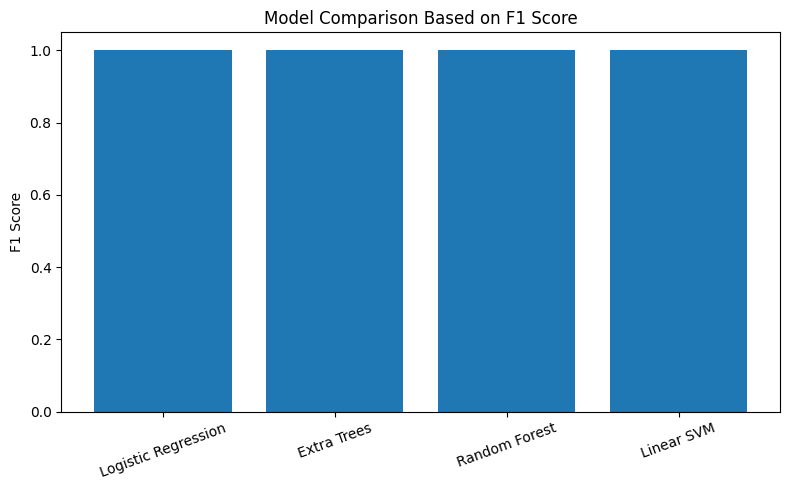

In [23]:
import matplotlib.pyplot as plt 

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.xticks(rotation=20)

plt.title("Model Comparison Based on F1 Score")

plt.ylabel("F1 Score")

plt.tight_layout()

plt.show()

Cell 13 - Best Model 
-

In [24]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model:", best_model_name)

best_model = trained_models[best_model_name]

Best Model: Logistic Regression


Cell 14 - Save Best Model
-

In [25]:
pickle.dump(
    best_model,
    open("../models/best_model.pkl","wb")

)

pickle.dump(
    tfidf,
    open("../models/tfidf.pkl","wb")

)

pickle.dump(
    scaler,
    open("../models/scaler.pkl","wb")
)

Cell 15 - Cross-Validation
-

In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Cross Validation F1 Scores:", scores)
print("Average F1:", scores.mean())

Cross Validation F1 Scores: [1. 1. 1. 1. 1.]
Average F1: 1.0
